In [1]:
# === Direct ARCO → Zarr for: u850, v850, z500, tcwv, msl ===
import os
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm
import dask.bag as db

import gcsfs
fs = gcsfs.GCSFileSystem(token='anon')  # public access
import matplotlib.pyplot as plt
import xesmf as xe
import cartopy.crs as ccrs
proj = ccrs.NorthPolarStereo(0,70)
import glob

from dask.distributed import LocalCluster,Client

In [2]:

cluster = LocalCluster(n_workers=32, memory_limit='6GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 64,Total memory: 192.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35935,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40025,Total threads: 2
Dashboard: http://127.0.0.1:44727/status,Memory: 6.00 GiB
Nanny: tcp://127.0.0.1:46729,


2025-12-08 16:58:48,307 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:42331' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('concatenate-cbd62dc72710ffa8c34be5176894efb5', 167, 0, 0), ('concatenate-cbd62dc72710ffa8c34be5176894efb5', 225, 0, 0), ('rechunk-split-6ec4d68dc8b9bb40dafd7f1f87861ebe', 430), ('store-map-3712b37c6e57bd460111043b5fc18af0', 63, 0, 0), ('rechunk-split-6ec4d68dc8b9bb40dafd7f1f87861ebe', 441)} (stimulus_id='handle-worker-cleanup-1765209528.306568')
2025-12-08 16:58:48,469 - distributed.nanny - WARNING - Restarting worker


In [3]:
from pyproj import CRS, Transformer

def make_npstereo_grid(true_scale_lat=70):
    """
    Make target grid in npstereo meters, with corresponding lon/lat for xESMF.
    Returns xr.Dataset with coords x (m), y (m), lon(y,x), lat(y,x).
    """
    # Projection
    npstereo = CRS.from_proj4(f"+proj=stere +lat_0=90 +lat_ts={true_scale_lat} +lon_0=0 +datum=WGS84 +units=m")
    geo  = CRS.from_epsg(4326)
    tfm = Transformer.from_crs(npstereo, geo, always_xy=True)
    x = np.linspace(-10_000_000,5_000_000., 128)
    y = np.linspace(-10_000_000,5_000_000., 128)
    
    xx, yy = np.meshgrid(x, y)

    lon, lat = tfm.transform(xx, yy)

    ds_out = xr.Dataset(
        coords=dict(
            x=("x", x),
            y=("y", y),
            lon=(("y","x"), lon),
            lat=(("y","x"), lat),
        )
    )
    return ds_out

In [4]:
target_grid = make_npstereo_grid(true_scale_lat=70)
dummy_data = xr.open_dataset('/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197901.850.u.nc').isel(lev=0, time=0).u
regridder = xe.Regridder(dummy_data, target_grid, 'bilinear', periodic=True)

In [5]:
def preprocess_ds(ds):
    if 'lev' in ds:
        ds = ds.isel(lev=0, drop=True)
    elif 'plev' in ds:
        ds = ds.isel(plev=0, drop=True)
    
    return  ds.coarsen(time=8).mean()#.load()

list_files_u850 = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/pl/*.850.u.nc')
list_files_v850 = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/pl/*.850.v.nc')
list_files_msl = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/sfc/*.msl.*')
list_files_z500 = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/pl/*.500.z.nc')

ds_u = xr.open_mfdataset(list_files_u850, parallel=True, preprocess=preprocess_ds, chunks = dict(time=256), engine='netcdf4').chunk(dict(time=256))
ds_v = xr.open_mfdataset(list_files_v850, parallel=True, preprocess=preprocess_ds, chunks = dict(time=256), engine='netcdf4').chunk(dict(time=256))
ds_msl = xr.open_mfdataset(list_files_msl, parallel=True, preprocess=preprocess_ds, chunks = dict(time=256), engine='netcdf4').chunk(dict(time=256))
ds_z = xr.open_mfdataset(list_files_z500, parallel=True, preprocess=preprocess_ds, chunks = dict(time=256), engine='netcdf4').chunk(dict(time=256))

In [6]:
ds = xr.Dataset(dict(u850=ds_u.u, v850=ds_v.v, msl = ds_msl.msl, z500=ds_z.z))
ds = ds.assign_coords(time=pd.date_range('1979-01-01', freq='D', periods=ds.time.size))
ds = regridder(ds)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fc2396dbd80>
Traceback (most recent call last):
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [8]:
from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")

chunks = (256,128,128)  # ~year per chunk; 

enc = {'u850': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'v850': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'z500': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'msl': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
#        'data_mean': {"compressors": compressor, "dtype": "float32", "chunks": (1,128,128)},
#        'data_std': {"compressors": compressor, "dtype": "float32", "chunks": (1)},
       'lon': {"compressors": compressor, "dtype": "float32", "chunks": (128,128)},
       'lat': {"compressors": compressor, "dtype": "float32", "chunks": (128,128)},
        "y": {"compressors": compressor}, 
        "x": {"compressors": compressor}, 
        "time": {"compressors": compressor}}

zarr_out_lowres = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr"
ds.chunk(dict(time=256)).to_zarr(zarr_out_lowres, mode='w', encoding=enc)                       



/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
Exception ignored in: <function CachingFileManager.__del__ at 0x7fc2396dbd80>
Traceback (most recent call last):
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError

# Reload data and compute mean

In [13]:
ds = xr.open_zarr(zarr_out_lowres)

data_mean = ds.to_array('var_name').sel(time=slice('1979','2008')).mean('time').load()
data_std = ds.to_array('var_name').sel(time=slice('1979','2008')).std(['time','x','y']).load()
data_mean.attrs['train_period'] = '1979-2009'
data_std.attrs['train_period'] = '1979-2009'
ds['data_mean'] = data_mean
ds['data_std'] = data_std

ds[['data_mean','data_std']].to_zarr(zarr_out_lowres, mode='a', 
                                     encoding={'data_mean': {"compressors": compressor, "dtype": "float32", "chunks": (1,128,128)},
                                                 'data_std': {"compressors": compressor, "dtype": "float32", "chunks": (1)},})                    


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [14]:
ds = xr.open_zarr(zarr_out_lowres)


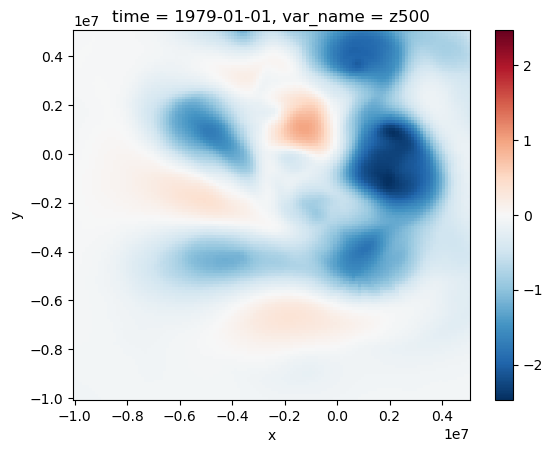

In [27]:
((ds.z500.isel(time=0) - ds.data_mean.sel(var_name='z500'))/ds.data_std.sel(var_name='z500')).plot()

In [18]:
len(ds.u850.data.chunks[0])

16802

In [8]:
# ds = ds.chunk(dict(time=1024))
ds = regridder(ds)
ds = ds.coarsen(time=8, boundary='trim').mean()

In [23]:
len(ds.chunks['time'])

526

In [ ]:
data_mean = ds.to_array('var_name').mean('time').load()
data_std = ds.to_array('var_name').std('time').load()


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 106.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
def preprocess_ds(ds):
    if 'lev' in ds:
        ds = ds.isel(lev=0, drop=True)
    elif 'plev' in ds:
        ds = ds.isel(plev=0, drop=True)
    return  ds#regridder(ds).resample(time='D').mean()

list_files_u850 = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/pl/*.850.u.nc')
list_files_v850 = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/pl/*.850.v.nc')
list_files_msl = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/sfc/*.msl.*')
list_files_z500 = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/pl/*.500.z.nc')

ds_u = xr.open_mfdataset(list_files_u850, parallel=True, preprocess=preprocess_ds)
ds_v = xr.open_mfdataset(list_files_v850, parallel=True, preprocess=preprocess_ds)
ds_msl = xr.open_mfdataset(list_files_msl, parallel=True, preprocess=preprocess_ds)
ds_z500 = xr.open_mfdataset(list_files_z500, parallel=True, preprocess=preprocess_ds)
ds = xr.Dataset(dict(u850=ds_u.u, v850=ds_v.v, msl = ds_msl.msl, z500=ds_z500.z))

In [ ]:
data_mean = ds.to_array('var_name').mean('time').load()
data_std = ds.to_array('var_name').std('time').load()


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 141.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 136.22 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


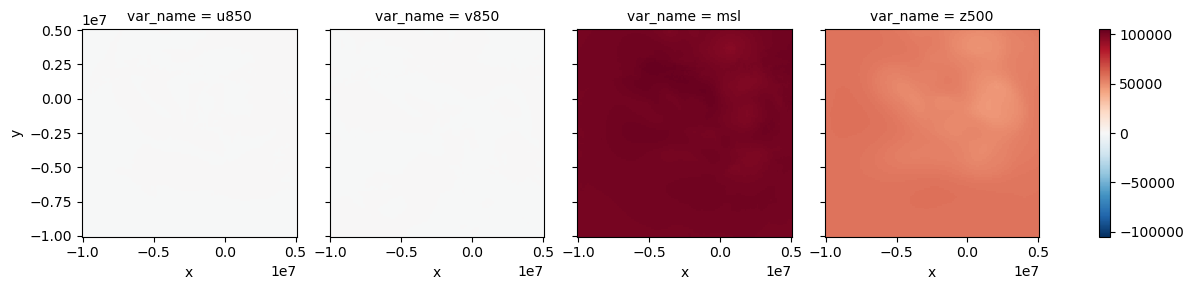

In [32]:
ds.isel(time=0).to_array('var_name').plot(col='var_name')

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 38.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


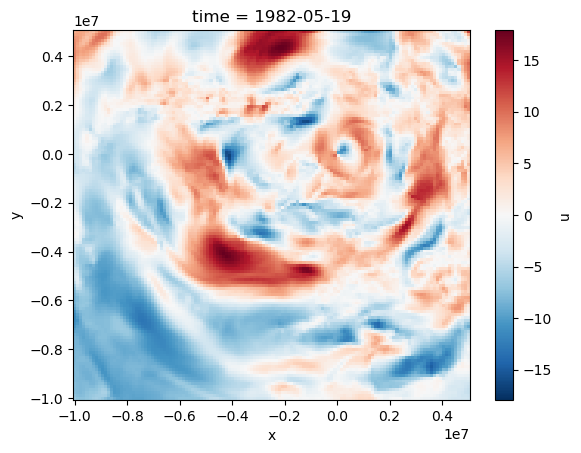

In [18]:
ds.isel(time=1234).u.plot()

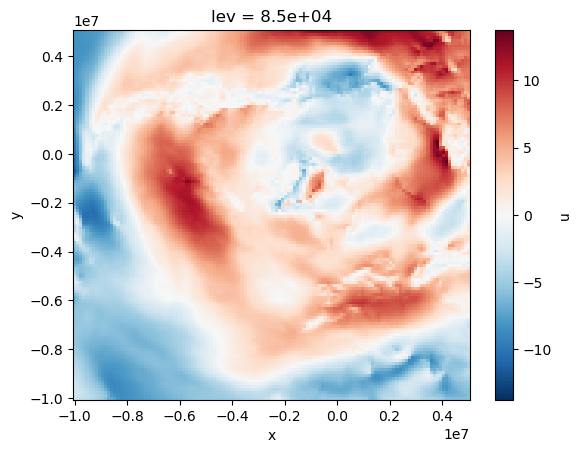

In [ ]:
list_files = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/pl/*.850.u.nc')
all_maps = []

ds = xr.open_dataset('/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197901.850.u.nc').drop('level')
regridder(ds).mean('time').u.plot()

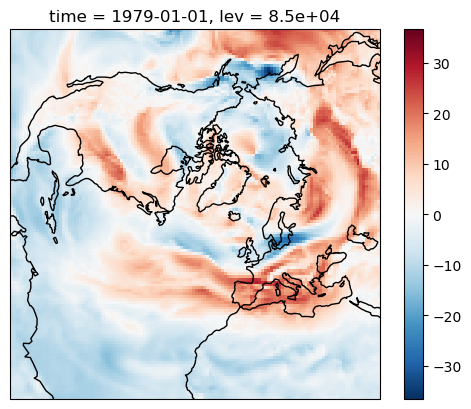

In [32]:
plot = regridder(dummy_data).plot( subplot_kws=dict(projection=proj))
plot.axes.coastlines()

In [3]:
import glob

In [ ]:
list_variable = glob.glob('/Data/gfi/share/Reanalysis/ERA-5/pl/*.850.u.nc')


['/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197901.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197902.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197903.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197904.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197905.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197906.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197907.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197908.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197909.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197910.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197911.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.197912.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.198001.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.198002.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.198003.850.u.nc',
 '/Data/gfi/share/Reanalysis/ERA-5/pl/ea.ans.198004.850